In [2]:
import agama
agama.setUnits(mass=1, length=1, velocity=1)

from constants import *
from integrants_with_binning import integrate_leapfrog_barred
from sample_from_density import sample_from_density_grid
from densities import *
from potentials import *
from utils import *
from model import *
from CylindricalSpline import get_phi_m, get_acc, evaluate_phi_axisymmetric

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import pandas as pd
import pickle

import time

path = '/Users/hanyuan/Dropbox/python_script/SchwarMAX/'
def get_dict_data(path):

    with open(path + 'mock_Nbody_bar_XY_withRot.pkl', 'rb') as f:
        bin_dict = pickle.load(f)

    # voronoi binning mapping and data
    num_per_bin = jnp.array(bin_dict['num_per_bin'])
    total_bins = jnp.array(bin_dict['total_bins'])
    bin_mapping = jnp.array(bin_dict['bin_mapping'])
    surface_density = jnp.array(bin_dict['surface_density'])
    V_data = jnp.array(bin_dict['V_mean'])
    sigma_data = jnp.array(bin_dict['V_sigma'])
    h1_data = jnp.array(bin_dict['h1'])
    h2_data = jnp.array(bin_dict['h2'])
    h3_data = jnp.array(bin_dict['h3'])
    h4_data = jnp.array(bin_dict['h4'])
    v0 = jnp.array(bin_dict['v0'])
    s = jnp.array(bin_dict['s'])
    alpha, beta, gamma = bin_dict['orientation']

    # V_data_err = jnp.where(0.1 * jnp.fabs(V_data) < 10, 10, 0.1 * V_data)
    # sigma_data_err = jnp.where(0.1 * jnp.fabs(sigma_data) < 5, 5, 0.1 * sigma_data)
    # h1_data_err = jnp.where(0.1 * jnp.fabs(h1_data) < 0.03, 0.03, 0.1 * jnp.fabs(h1_data))
    # h2_data_err = jnp.where(0.1 * jnp.fabs(h2_data) < 0.03, 0.03, 0.1 * jnp.fabs(h2_data))
    # h3_data_err = jnp.where(0.1 * jnp.fabs(h3_data) < 0.03, 0.03, 0.1 * jnp.fabs(h3_data))
    # h4_data_err = jnp.where(0.1 * jnp.fabs(h4_data) < 0.03, 0.03, 0.1 * jnp.fabs(h4_data))
    V_data_err = jnp.array(bin_dict['V_mean_err'])
    sigma_data_err = jnp.array(bin_dict['V_sigma_err'])
    h1_data_err = jnp.array(bin_dict['h1_err'])
    h2_data_err = jnp.array(bin_dict['h2_err'])
    h3_data_err = jnp.array(bin_dict['h3_err'])
    h4_data_err = jnp.array(bin_dict['h4_err'])

    # df_Rzphi_data = pd.read_csv(path + 'mock_axisymmetric_disc_Rzphi.csv')
    # Rzphi_density_data = jnp.array(df_Rzphi_data['mass'].to_numpy()).astype(jnp.float32)
    with open(path + 'mock_axisymmetric_disc_Rzphi.pkl', 'rb') as f:
        Rzphi_density_data = pickle.load(f)

    R_grid, z_grid, phi_grid = Rzphi_density_data['R_grid'], Rzphi_density_data['z_grid'], Rzphi_density_data['phi_grid']
    dR = np.unique(R_grid)[1] - np.unique(R_grid)[0]
    dz = np.unique(z_grid)[1] - np.unique(z_grid)[0]
    dphi = np.unique(phi_grid)[1] - np.unique(phi_grid)[0]
    sample_for_integration = Rzphi_density_data['sample_for_integration']

    from scipy.stats import qmc
    X_regular_grid, Y_regular_grid = bin_dict['X_regular_grid'], bin_dict['Y_regular_grid']
    dX = jnp.unique(X_regular_grid)[1] - jnp.unique(X_regular_grid)[0]
    dY = jnp.unique(Y_regular_grid)[1] - jnp.unique(Y_regular_grid)[0]
    sampler = qmc.Sobol(d=3, scramble=False)
    sample = sampler.random_base2(m=10)


    dict_data = {
        # 'w0': w0,
        'v0': v0,
        's': s,

        # 'Rzphi_density_data': Rzphi_density_data,
        'XY_density_data': surface_density,
        'V_data': V_data,
        'V_data_err': V_data_err,
        'sigma_data': sigma_data,
        'sigma_data_err': sigma_data_err,
        'h1_data': h1_data,
        'h1_data_err': h1_data_err,
        'h2_data': h2_data,
        'h2_data_err': h2_data_err,
        'h3_data': h3_data,
        'h3_data_err': h3_data_err,
        'h4_data': h4_data,
        'h4_data_err': h4_data_err,
        'num_per_bin': num_per_bin,
        'bin_mapping': bin_mapping,
        'total_bins': total_bins.item(),

        'R_grid': R_grid,
        'z_grid': z_grid,
        'phi_grid': phi_grid,
        'dR': dR,
        'dz': dz,
        'dphi': dphi,
        'sample_for_integration': sample_for_integration,

        'X_regular_grid': X_regular_grid,
        'Y_regular_grid': Y_regular_grid,
        'dX': dX,
        'dY': dY,
        'sample_for_integration_XY': sample,
    }

    return dict_data


@jax.jit
def Ferrers_density(x, y, z, params):

    '''
    params include: 'logM_bar', 'Rs_bar', 'q_bar', 'p_bar'
    '''
    p, q, Rs = params['p_bar'], params['q_bar'], params['Rs_bar']
    M = 10.0 ** params['logM_bar']
    r = jnp.sqrt(x**2 + (y / p)**2 + (z / q)**2)
    rho = 105 * M / (32 * jnp.pi * p * q * Rs**3) * (1 - (r / Rs)**2)**2
    rho = jnp.where(r <= Rs, rho, 0.0)
    return rho

@jax.jit
def Dehnen_density(x, y, z, params):

    '''
    Dehnen profile: rho = (M / (4π p q Rs^3)) * (r/Rs)^(-n) * (1 + r/Rs)^(n-4), where n = 2
    '''

    p, q, Rs = params['p_bar'], params['q_bar'], params['Rs_bar']
    M = 10.0 ** params['logM_bar']
    r = jnp.sqrt(x**2 + (y / p)**2 + (z / q)**2) + EPSILON

    val = M / (4 * jnp.pi * p * q * Rs**3) * (r / Rs)**(-2) * (1 + r / Rs)**(-2) * jnp.exp(-(z / 3)**4) * jnp.exp(-(r / 10)**4)

    return val

def density_func(x, y, z, params):
    return Dehnen_density(x, y, z, params) + DoubleExponentialDisk_density(x, y, z, params)

# def density_func_agama(x):
#     return np.array(density_func(x[:, 0], x[:, 1], x[:, 2], params_dict))


In [16]:

dict_data = get_dict_data(path)

logMhalo_best_fit, logrho0_best_fit, logM_bar_best_fit, logRh_disk_best_fit, logRs_disk_best_fit, logHs_disk_best_fit, logRs_bar_best_fit,\
    alpha_best_fit, beta_best_fit, gamma_best_fit, logLM_best_fit, logOmega_bar = (11.8, 8.8, 10.4, 1.2, 0.45, -0.24, 0.3, 
                                                                                    30*np.pi/180, 20*np.pi/180, 130*np.pi/180, 0, 1.6)

# logMhalo_best_fit, logrho0_best_fit, logM_bar_best_fit, logRh_disk_best_fit, logRs_disk_best_fit, logHs_disk_best_fit, logRs_bar_best_fit,\
#     alpha_best_fit, beta_best_fit, gamma_best_fit, logLM_best_fit, logOmega_bar = (10.07, 9.22, 9.2, 1.95, 0.54, -0.94, 0.35, 0.73, 0.71, 2.45, -0.25, 1.48)  


alpha = alpha_best_fit * 180/np.pi
beta = beta_best_fit * 180/np.pi
gamma = gamma_best_fit * 180/np.pi
ground_truth = [logMhalo_best_fit,
                logrho0_best_fit,
                logM_bar_best_fit,
                logRh_disk_best_fit,
                logRs_disk_best_fit,
                logHs_disk_best_fit,
                logRs_bar_best_fit,
                alpha,
                beta,
                gamma,
                logLM_best_fit,
                logOmega_bar,
]


params_halo_pot = {
    'logM': ground_truth[0],
    'Rs':10 ** ground_truth[3],
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

params_dict = {
    'rho0_disc': 10 ** ground_truth[1],
    'Rd_disc': 10 ** ground_truth[4],
    'hz_disc': 10 ** ground_truth[5],
    'light_to_mass_ratio': 10 ** ground_truth[10],
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0,
    'alpha': ground_truth[7],
    'beta': ground_truth[8],
    'gamma': ground_truth[9],
    'logM_bar': ground_truth[2],
    'Rs_bar': 10 ** ground_truth[6],
    'Omega_bar': 10 ** ground_truth[11],
    'p_bar': 0.3,
    'q_bar': 0.3,
}

samples = np.array([
    np.random.normal(0, 5, 20000),
    np.random.normal(0, 5, 20000),
    np.random.normal(0, 2, 20000)
]).T


w0 = jnp.array(samples)
n_particles = w0.shape[0]
params_disk_rho = params_dict
NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-3, 30.0, 1e-3, 15.0, 8.
Nphi = 300
N_int = 10_000
dict_phi = get_phi_m(density_func, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

#=========================================== GET INITIAL VELOCITY ===================================================
@jax.jit
def dPhi_dz(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t z
    d = 5e-3
    return (potential_func(x, y, z+d, dict_phi, params_halo) - potential_func(x, y, z-d, dict_phi, params_halo)) / (2*d)

@jax.jit
def dPhi_dR(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t R
    d = 5e-3
    R = jnp.sqrt(x**2 + y**2)
    return (potential_func(R+d, 0, z, dict_phi, params_halo) - potential_func(R-d, 0, z, dict_phi, params_halo)) / (2*d)

@jax.jit
def get_jeans_moments(x_star, y_star, z_star, dict_phi, params_disc, params_halo, anisotropy_b=1.0):
    """
    Computes (v_mean, sigma_R, sigma_z, sigma_phi) for a star at (R, z).

    Parameters:
    -----------
    x_star, y_star, z_star : float
        Coordinates of the particle.
    density_fn : function
        Function returning stellar density nu(R, z).
    anisotropy_b : float
        sigma_R^2 / sigma_z^2. Default 1.0 (isotropic).
    """
    R_star = jnp.sqrt(x_star**2 + y_star**2)

    # --- Step 1: Compute Sigma_z (Vertical Integration) ---

    # Integrand: nu(R, z) * dPhi/dz
    def integrand(z_prime):
        return density_func(x_star, y_star, z_prime, params_disc) * dPhi_dz(x_star, y_star, z_prime, dict_phi, params_halo)

    # Integrate from z_star to infinity (e.g., 20 kpc)
    # Note: We assume symmetry, so we integrate |z| to infinity
    pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
    dx = pts[1] - pts[0]
    # integrand_val = integrand(pts)
    integrand_val = jax.vmap(integrand, in_axes = (0))(pts)
    integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)

    nu_val = density_func(x_star, y_star, z_star, params_disc)
    # if nu_val <= 0: return 0, 0, 0, 0

    sigma_z2 = (1.0 / nu_val) * integral_val

    sigma_z2 = jnp.maximum(sigma_z2, 0.0)

    sigma_z = jnp.sqrt(sigma_z2)

    # --- Step 2: Compute Sigma_R (Anisotropy assumption) ---
    sigma_R2 = anisotropy_b * sigma_z2
    sigma_R = jnp.sqrt(sigma_R2)

    # --- Step 3: Compute v_phi_total^2 (Radial Equation) ---
    # We need d(nu * sigma_R^2) / dR
    # Since sigma_R^2 = b * sigma_z^2, we need d(b * Integral) / dR

    # Define a helper to calculate the "Vertical Pressure" P_zz = nu * sigma_z^2 at any R
    def vertical_pressure(r_in):
        # We need to re-integrate at radius r_in to get the pressure there
        def integrand_r(z_prime):
            return density_func(r_in, 0, z_prime, params_disc) * dPhi_dz(r_in, 0, z_prime, dict_phi, params_halo)

        pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
        dx = pts[1] - pts[0]
        # integrand_val = integrand(pts)
        integrand_val = jax.vmap(integrand_r, in_axes = (0))(pts)
        integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
        return integral_val # This is (nu * sigma_z^2)

    # Calculate derivative w.r.t R using central difference
    dR = 5e-3
    Pzz_plus = vertical_pressure(R_star + dR)
    Pzz_minus = vertical_pressure(R_star - dR)
    d_nu_sigR2_dR = anisotropy_b * (Pzz_plus - Pzz_minus) / (2*dR)

    # Radial Jeans Equation:
    # v_phi_sq = sigma_R^2 + (R/nu) * d(nu*sigR^2)/dR + R * dPhi/dR
    term1 = sigma_R2
    term2 = (R_star / nu_val) * d_nu_sigR2_dR
    term3 = R_star * dPhi_dR(x_star, y_star, z_star, dict_phi, params_halo)

    v_phi_total_sq = term1 + term2 + term3

    # --- Step 4: Separate Rotation vs Dispersion ---
    # Assumption: sigma_phi approx sigma_R (Round velocity ellipsoid in plane)
    sigma_phi = sigma_R

    v_streaming_sq = v_phi_total_sq - sigma_phi**2

    v_streaming_sq = jnp.maximum(v_streaming_sq, 0.0)
    v_mean_phi = jnp.sqrt(v_streaming_sq)

    output = jax.lax.cond(nu_val<=0, lambda: (0.0, 0.0, 0.0, 0.0), lambda: (v_mean_phi, sigma_R, sigma_z, sigma_phi))

    return output


get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
# jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
def get_w0_new(w0, key1, key2, key3, n_particles):
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)
    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R # 2 sigma dispersion
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi
    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)
    return jnp.array([x, y, w0[:,2], vx, vy, vz]).T
key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
w0_new = get_w0_new(w0, key1, key2, key3, n_particles)


def _split(w):
    return w[:3], w[3:]

def _merge(r, v):
    return jnp.concatenate([r, v], axis=0)

@partial(jax.jit, static_argnames=('acc_fn', 'n_steps', 'unroll',))
def integrate_leapfrog_barred_traj(w0, acc_fn, n_steps, dt = 0.010, t0 = 0.0, Omega = 0.0, unroll=True):
    """Leapfrog (KDK) — returns final time and final state only.

    num_segments_Rzphi: int
        Number of segments for Rzphi bin counting. MUST equal to nRzphi.prod()
    num_segments_XY: int
        Number of segments for XY bin counting. MUST equal to nXY.prod()
    
    v0 and s are arrays of reference velocity and dispersion for each XY cell for the GH coefficent calculation. Length should equal to nXY.prod()
    """

    def step(carry, _):
        t, y = carry
        r, v = _split(y)

        # Gravity half-kick
        a0 = acc_fn(*r)
        v_half = v + 0.5 * dt * a0

        # Exact Omega-subflow for:
        #   xdot = vx + Omega*y, ydot = vy - Omega*x
        #   vxdot = Omega*vy,     vydot = -Omega*vx
        theta = Omega * dt
        c, s_theta = jnp.cos(theta), jnp.sin(theta)

        x_bar = r[0] + dt * v_half[0]
        y_bar = r[1] + dt * v_half[1]
        x_new = c * x_bar + s_theta * y_bar
        y_new = -s_theta * x_bar + c * y_bar
        z_new = r[2] + dt * v_half[2]

        vx_rot = c * v_half[0] + s_theta * v_half[1]
        vy_rot = -s_theta * v_half[0] + c * v_half[1]
        vz_rot = v_half[2]

        r_new = jnp.array([x_new, y_new, z_new])
        v_rot = jnp.array([vx_rot, vy_rot, vz_rot])
        t_new = t + dt

        # Gravity half-kick at updated position
        a1 = acc_fn(*r_new)
        v_new = v_rot + 0.5 * dt * a1
        y_new = _merge(r_new, v_new)
        return (t_new, y_new), (t_new, y_new)

    (_, _), (tN, wN) = jax.lax.scan(step, (t0, w0), xs=None, length=n_steps, unroll=unroll)

    return tN, wN 

_R = jnp.sqrt(w0_new[:,0]**2 + w0_new[:,1]**2)
_z = w0_new[:,2]

T_orb = jax.vmap(estimate_orbital_timescale, in_axes=(0, None, None, 0))(
    _R,
    potential_func,
    (dict_phi, params_halo_pot),
    _z
)

Omega_bar = 34.0
E_pot = jax.vmap(potential_func, in_axes=(0, 0, 0, None, None))(w0_new[:,0], w0_new[:,1], w0_new[:,2], dict_phi, params_halo_pot)
E_kin = 0.5 * (w0_new[:,3]**2 + w0_new[:,4]**2 + w0_new[:,5]**2)
E_J = E_pot + E_kin - Omega_bar * (w0_new[:,3] * w0_new[:,1] - w0_new[:,4] * w0_new[:,0])
E_J.block_until_ready()
print('nothing', Omega_bar)

w0_new = w0_new[jnp.argsort(E_J)]
w0_lowE = w0_new[:10000, :]
w0_highE = w0_new[10000:, :]
T_orb_lowE = T_orb[jnp.argsort(E_J)][:10000]
T_orb_highE = T_orb[jnp.argsort(E_J)][10000:]

N_step_per_orb = 200
N_dynamical_time = 25
dt = T_orb_lowE / N_step_per_orb
time_integrate = T_orb_lowE * N_dynamical_time
N_steps = N_step_per_orb * N_dynamical_time
#=========================================== Integrate orbits =======================================================
@jax.jit
def acc_fn(x, y, z):
    a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
    a_disk = get_acc(x, y, z, dict_phi)
    return a_halo + a_disk

time_start = time.time()
_integrate_vmap = jax.vmap(integrate_leapfrog_barred_traj, 
                        in_axes=(0, None, None, 0, None, None, None))
tN1, wN1 = _integrate_vmap(w0_lowE, acc_fn, N_steps, dt, 0.0, -Omega_bar, False)
tN1.block_until_ready()
time_end = time.time()
print(f"Time taken to integrate orbits with reconstructed potential: {time_end - time_start:.2f} seconds")

N_step_per_orb = 100
N_dynamical_time = 50
dt = T_orb_highE / N_step_per_orb
time_integrate = T_orb_highE * N_dynamical_time
N_steps = N_step_per_orb * N_dynamical_time
#=========================================== Integrate orbits =======================================================
@jax.jit
def acc_fn(x, y, z):
    a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
    a_disk = get_acc(x, y, z, dict_phi)
    return a_halo + a_disk

time_start = time.time()
_integrate_vmap = jax.vmap(integrate_leapfrog_barred_traj, 
                        in_axes=(0, None, None, 0, None, None, None))
tN2, wN2 = _integrate_vmap(w0_highE, acc_fn, N_steps, dt, 0.0, -Omega_bar, False)
tN2.block_until_ready()
time_end = time.time()
print(f"Time taken to integrate orbits with reconstructed potential: {time_end - time_start:.2f} seconds")

tN = jnp.concatenate([tN1, tN2], axis=0)
wN = jnp.concatenate([wN1, wN2], axis=0)

x_lf, y_lf, z_lf = wN[:,:,0].flatten(), wN[:,:,1].flatten(), wN[:,:,2].flatten()
vx_lf, vy_lf, vz_lf = wN[:,:,3].flatten(), wN[:,:,4].flatten(), wN[:,:,5].flatten()
print("Leapfrog integration done.")

x_orb = wN[:,:,0]
y_orb = wN[:,:,1]
z_orb = wN[:,:,2]
vx_orb = wN[:,:,3]
vy_orb = wN[:,:,4]
vz_orb = wN[:,:,5]
R_orb = jnp.sqrt(x_orb**2 + y_orb**2)
Lz_orb = (vx_orb * y_orb - vy_orb * x_orb)

E_pot = jax.vmap(potential_func, in_axes=(0, 0, 0, None, None))(x_orb, y_orb, z_orb, dict_phi, params_halo_pot)
E_kin = 0.5 * (vx_orb**2 + vy_orb**2 + vz_orb**2)
E_J = E_pot + E_kin - Omega_bar * Lz_orb

E_J.block_until_ready()
print('nothing', Omega_bar)


nothing 34.0
Time taken to integrate orbits with reconstructed potential: 17.36 seconds
Time taken to integrate orbits with reconstructed potential: 17.23 seconds
Leapfrog integration done.
nothing 34.0


In [20]:
_integrate_vmap = jax.vmap(integrate_leapfrog_barred, 
                    in_axes=(
                            0, None, None, 0, None, None, None, 
                                None, None, None, 
                                None, None, 
                                None, None, None, 
                                None, None, None))

n_particles = w0.shape[0]
v0 = dict_data['v0']
s = dict_data['s']
num_per_bin = dict_data['num_per_bin']
bin_mapping = dict_data['bin_mapping']
Rzphi_lim_grid = jnp.array([[0,10.],[-3,3],[-jnp.pi, jnp.pi]])
xy_lim_grid = jnp.array([[-12.,12.],[-4.,4.]])
Rzphi_n_grid = jnp.array([10,6,6])
xy_n_grid = jnp.array([60,40])
Rzphi_n_tot = 360
num_Vbin = len(v0)

alpha, beta, gamma = params_disk_rho['alpha'], params_disk_rho['beta'], params_disk_rho['gamma']
rotation_matrix = makeRotationMatrix(alpha, beta, gamma)

time = time_integrate #Gyr
n_steps = N_steps
dt = dt
unroll = False
initial_time = 0.0
Rzphi_bin_counts, surface_density, h1, h2, h3, h4 = _integrate_vmap(
                    w0_highE, acc_fn, n_steps, dt, initial_time, -Omega_bar, unroll,
                    num_Vbin, bin_mapping, num_per_bin,
                    Rzphi_lim_grid, xy_lim_grid,
                    Rzphi_n_grid, xy_n_grid, Rzphi_n_tot,
                    v0, s, rotation_matrix)
A_Rzphi_2 = Rzphi_bin_counts.T / n_steps
A_xy_2 = surface_density.T / n_steps
A_h1_2 = h1.T
A_h2_2 = h2.T
A_h3_2 = h3.T
A_h4_2 = h4.T

100it [00:00, 1279.84it/s]


781 Bad orbits


25it [00:00, 179.26it/s]


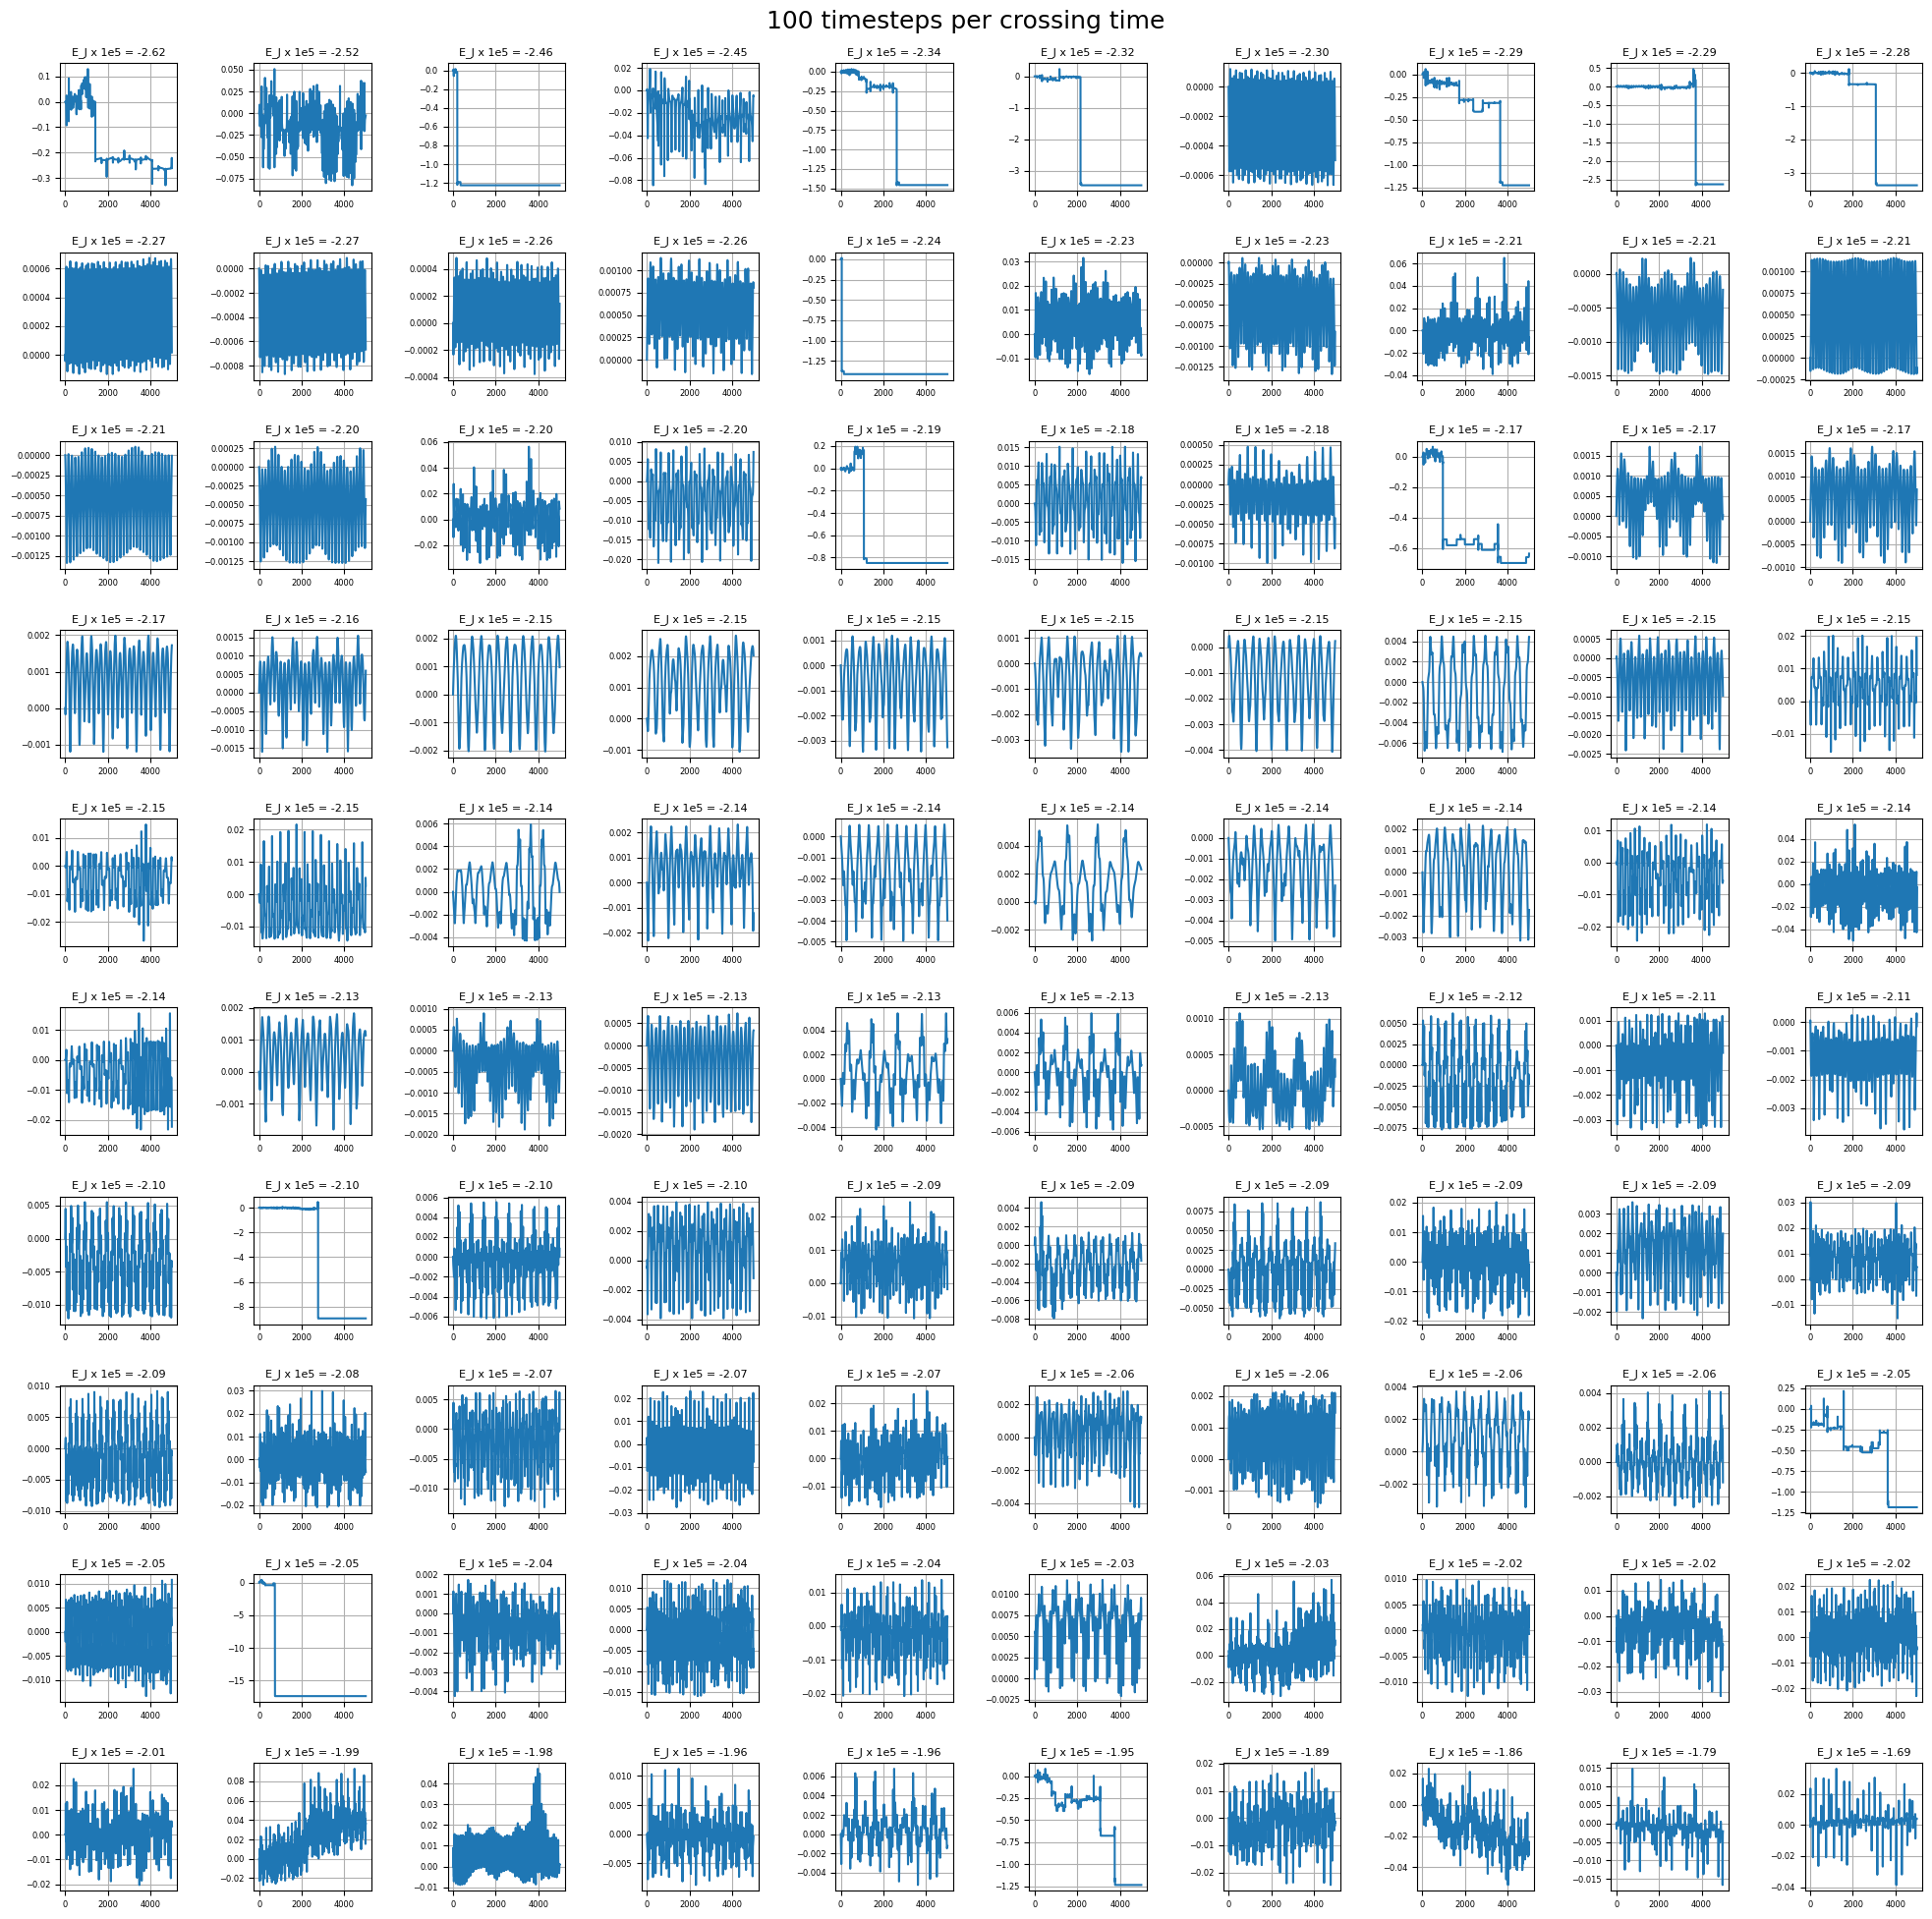

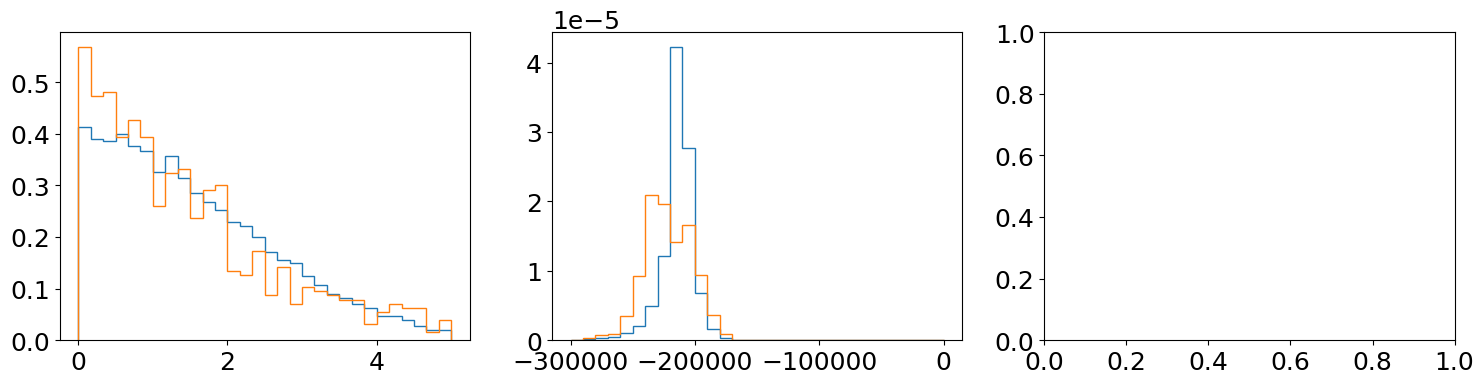

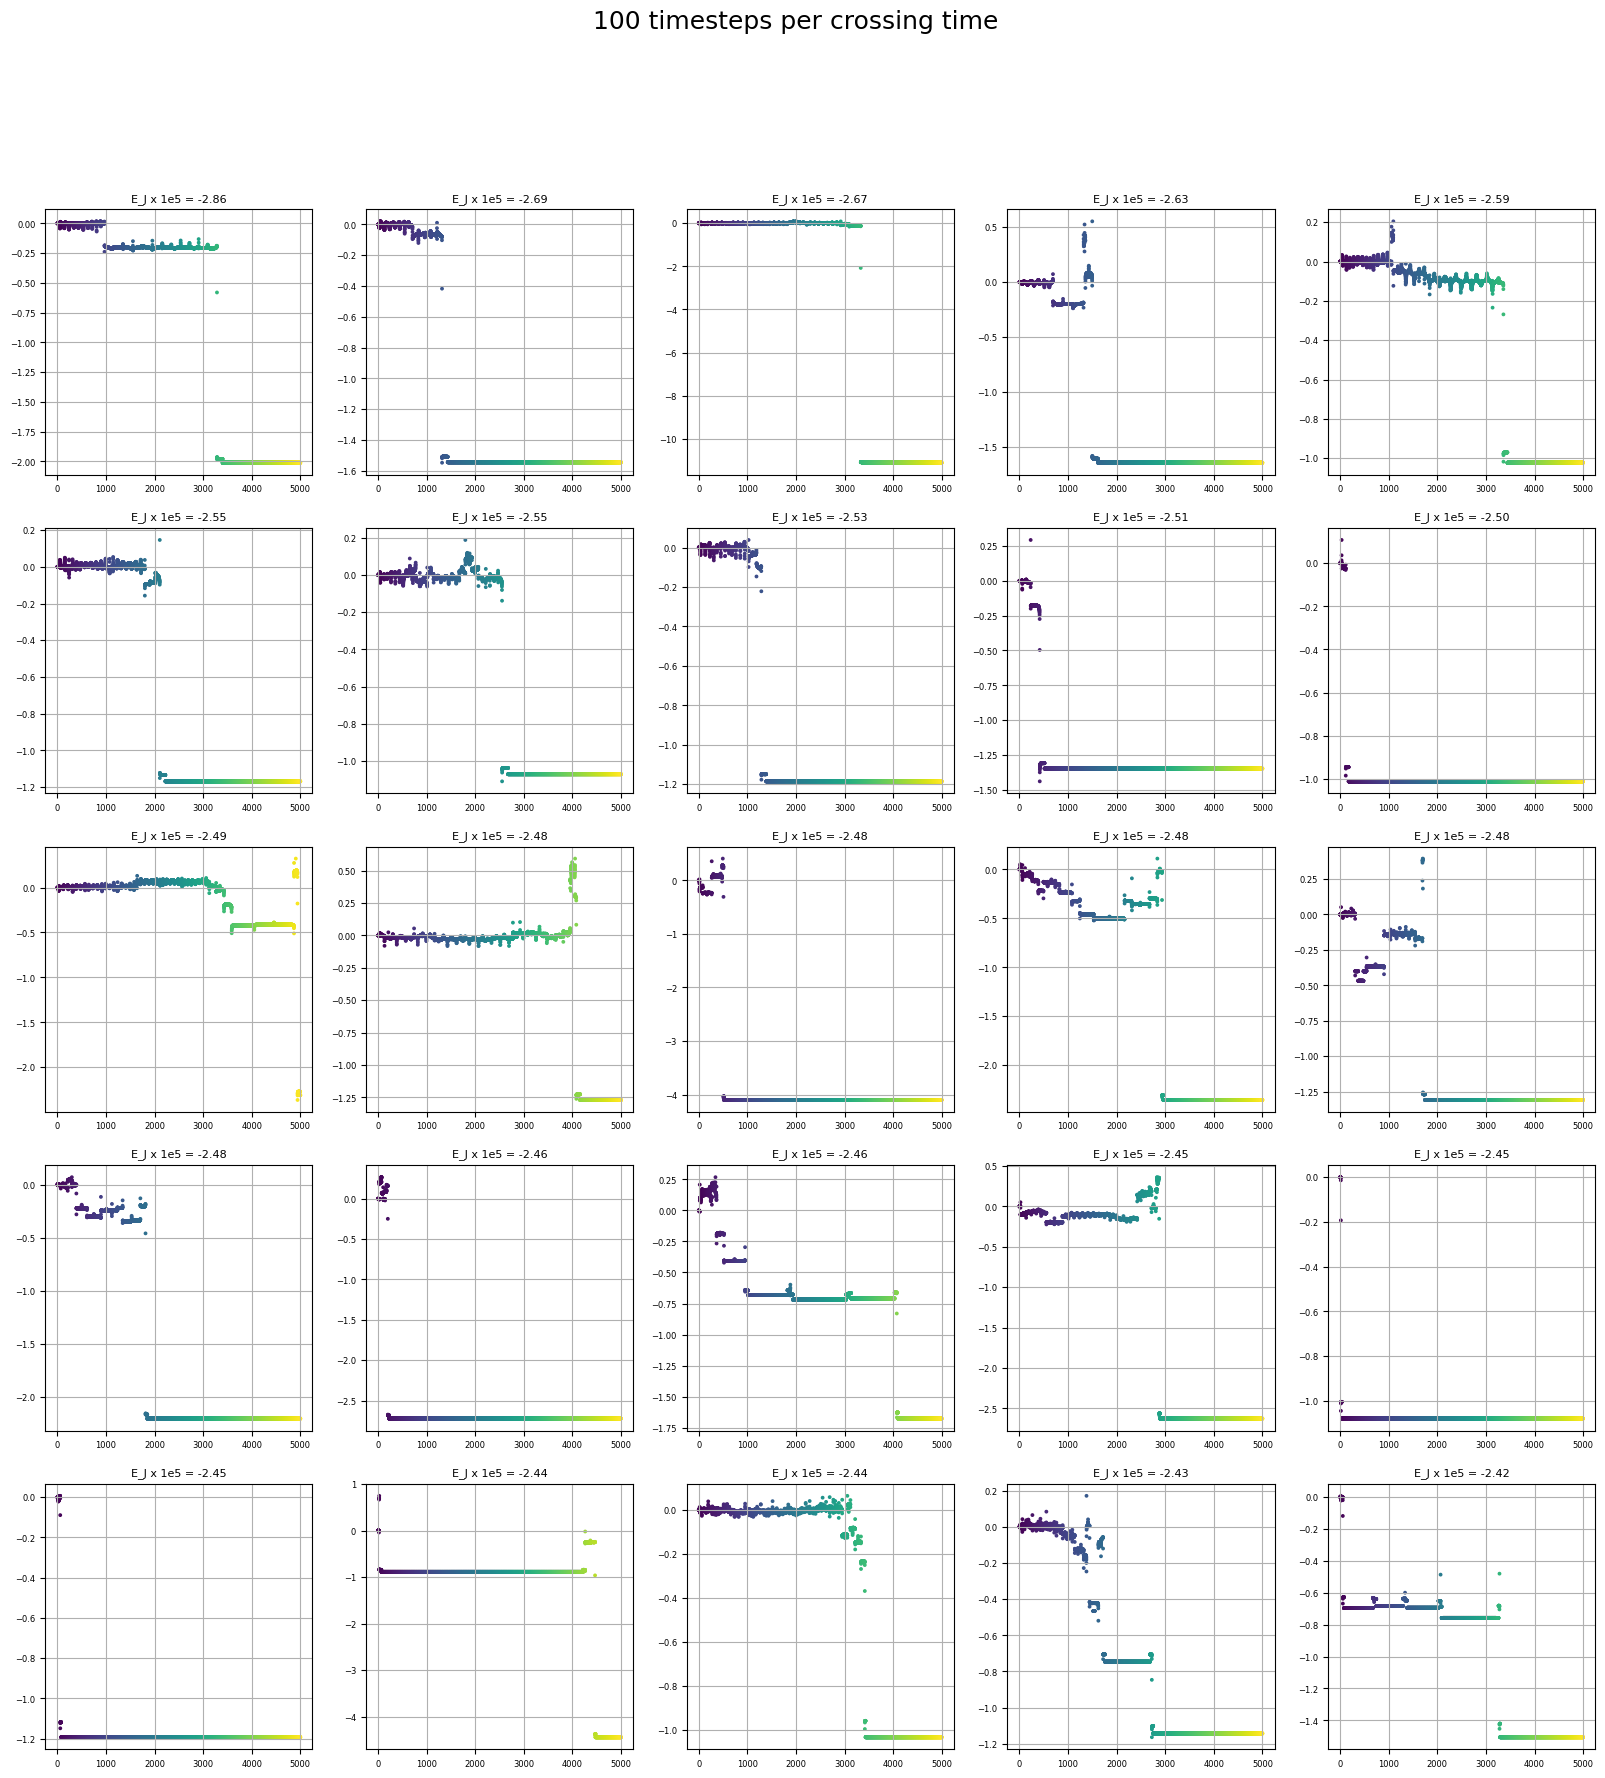

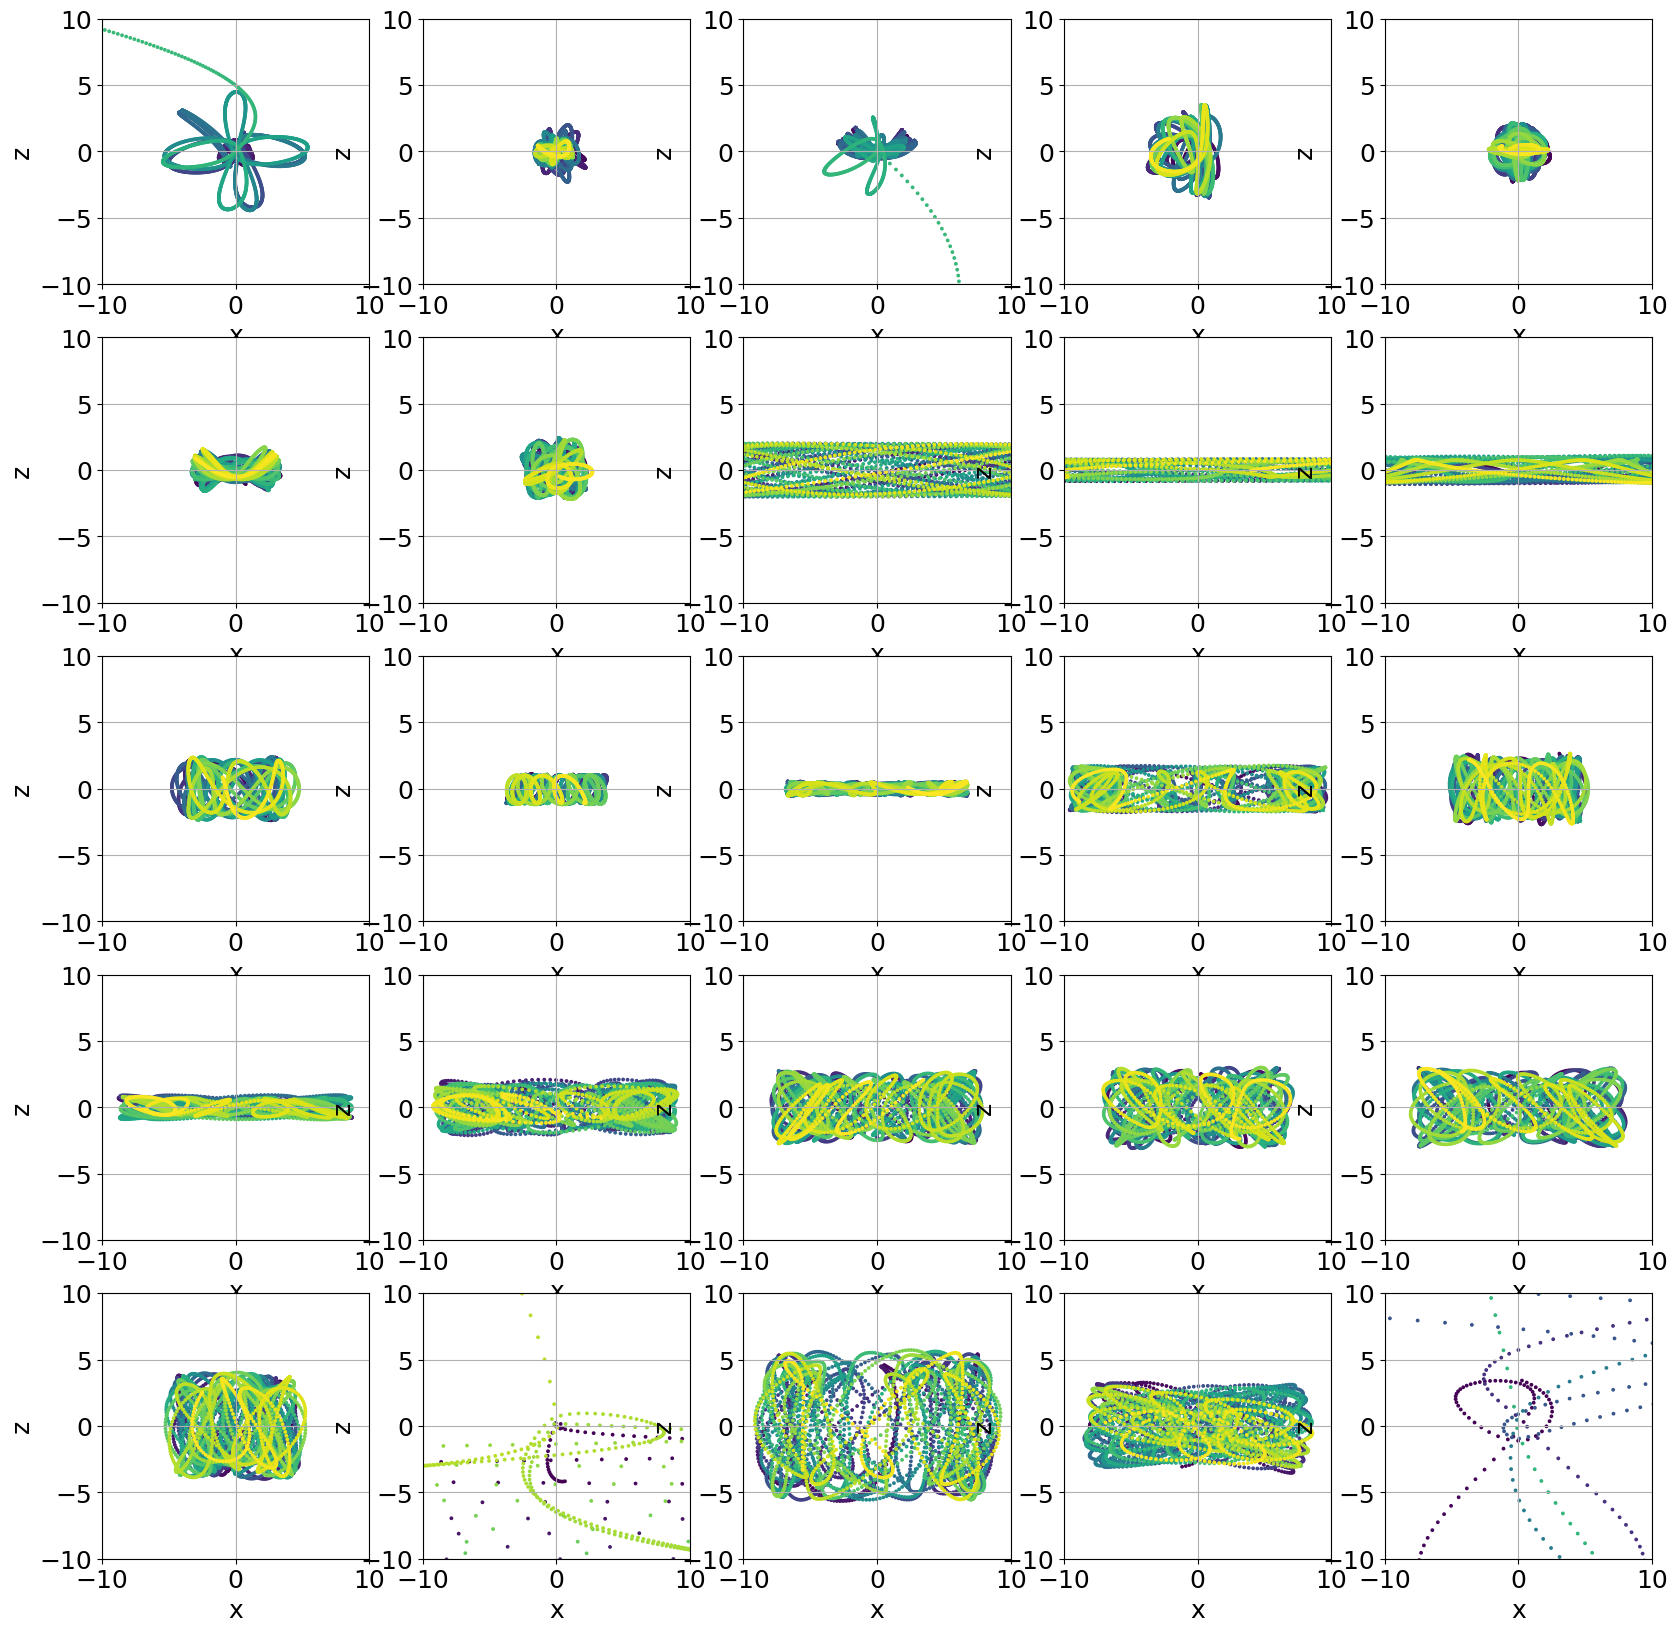

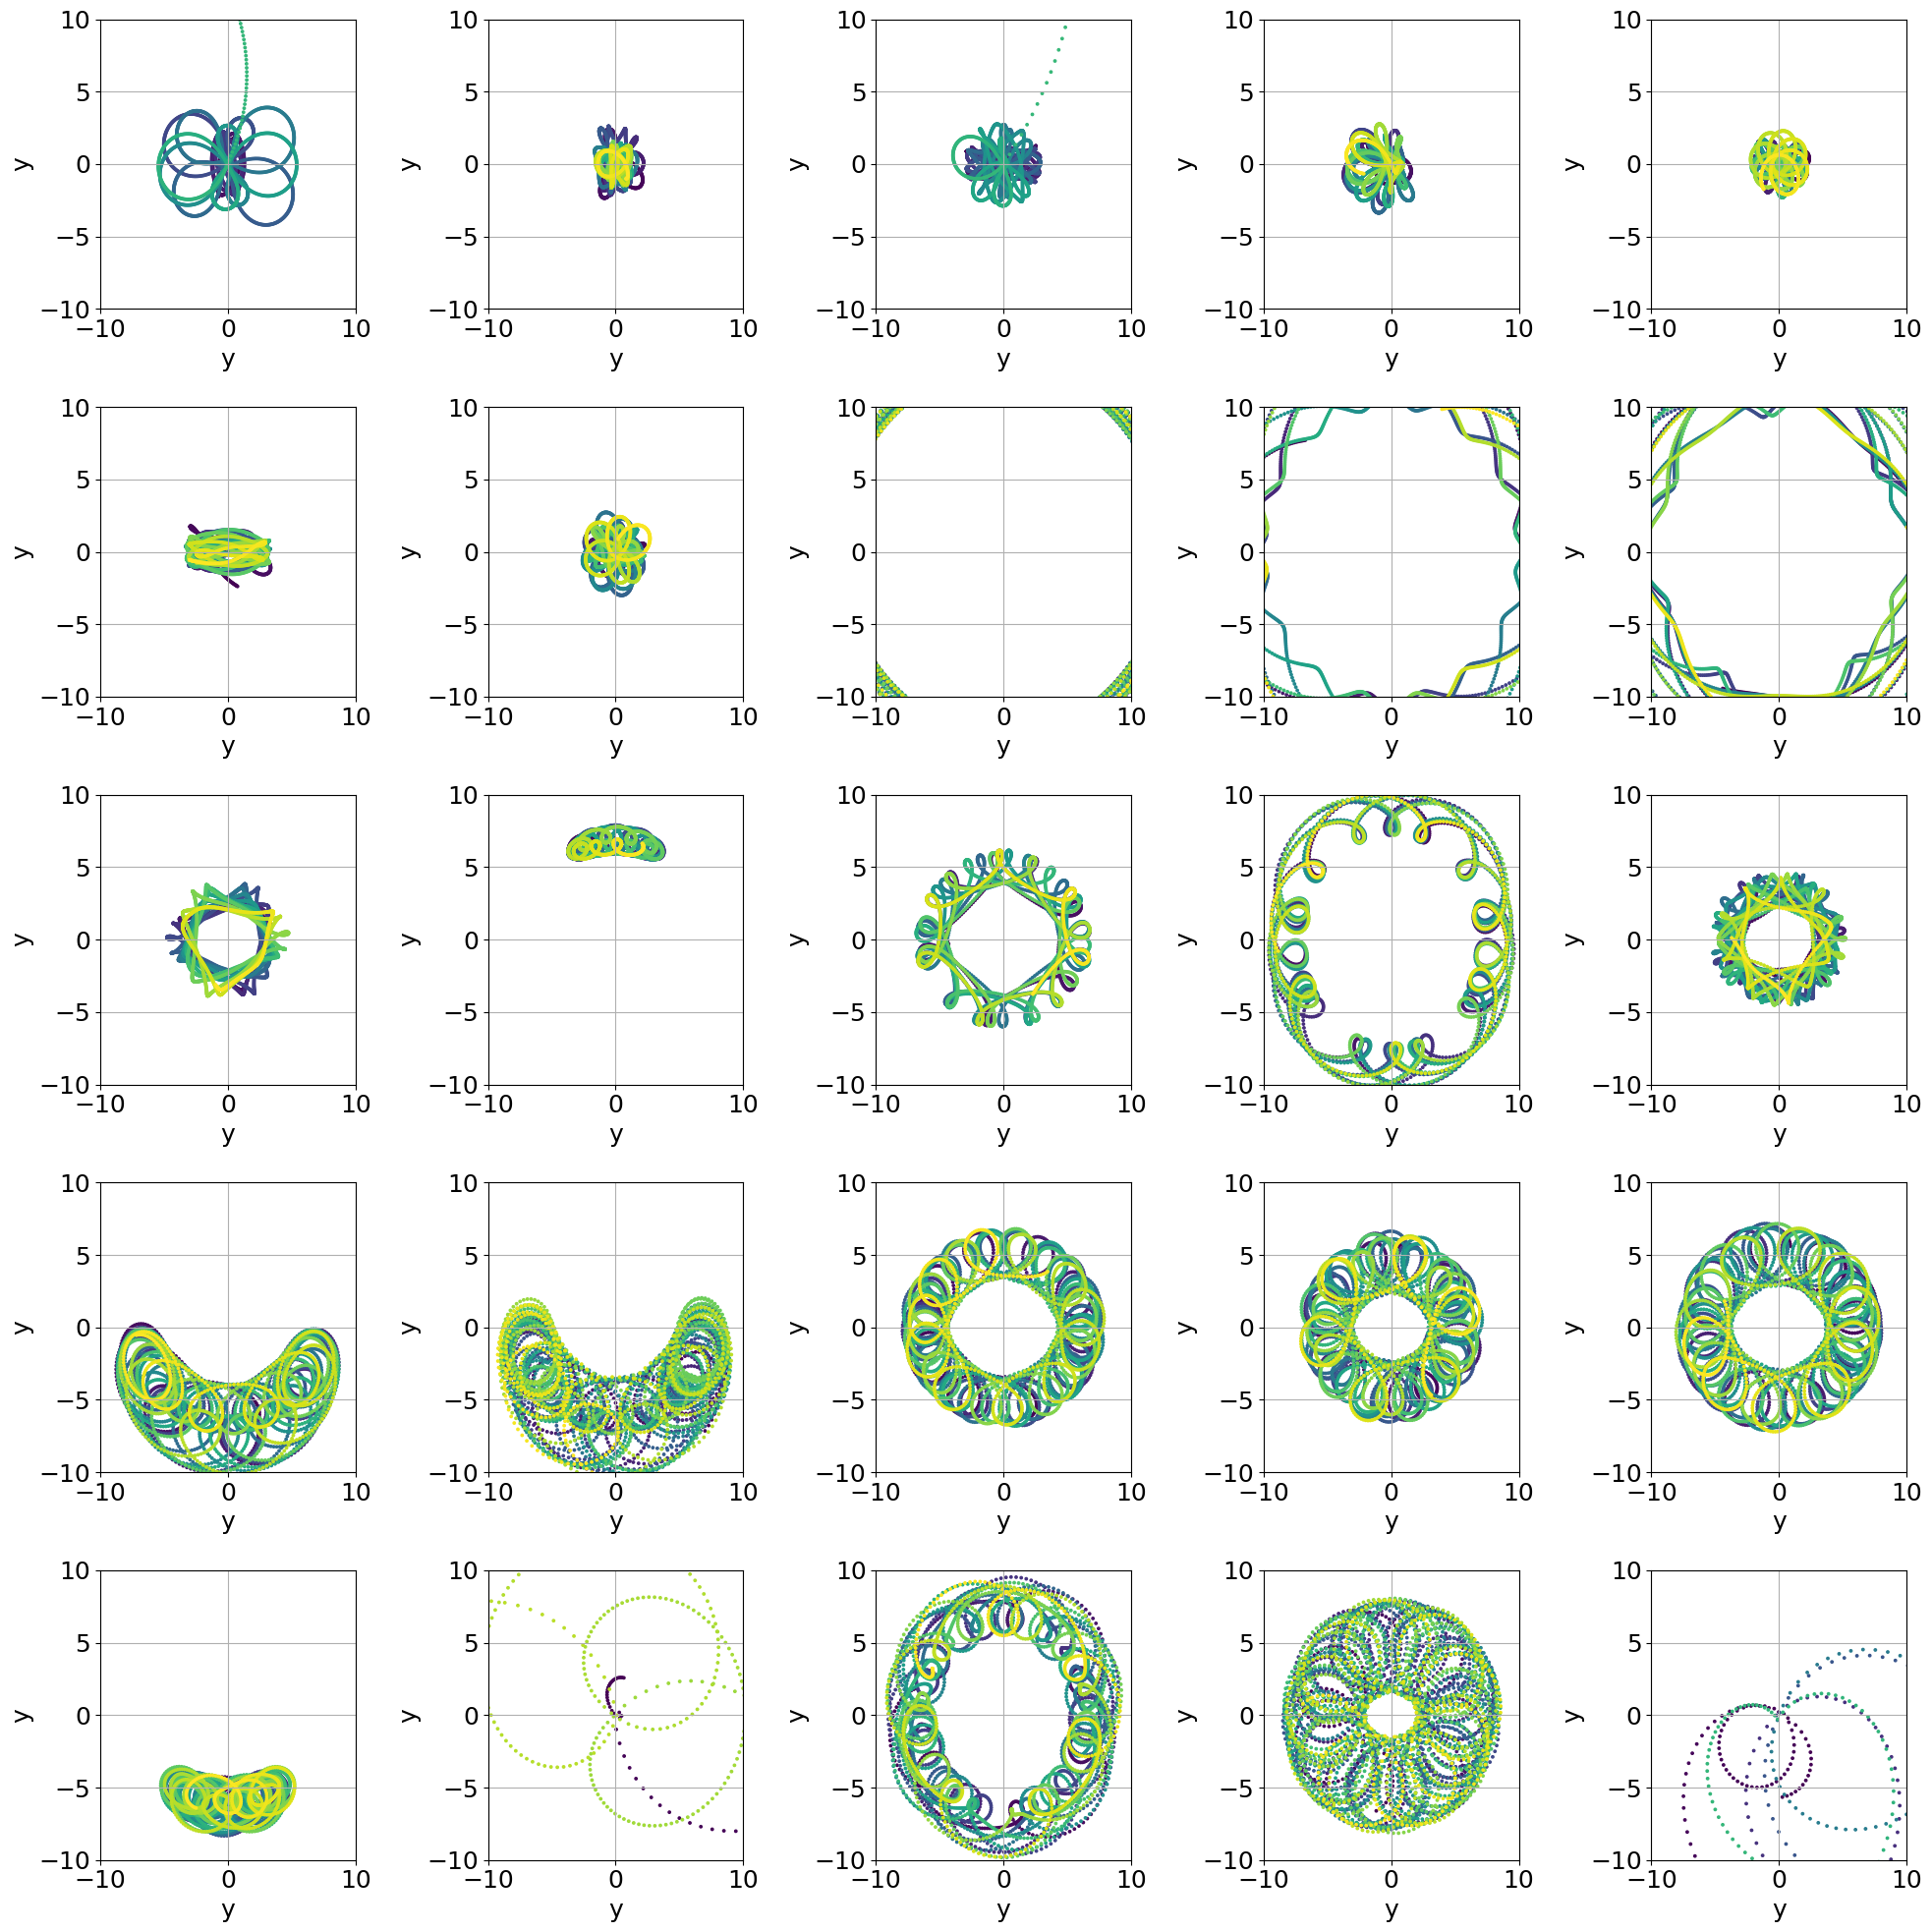

In [17]:
E_J_argsort = np.argsort(E_J[:,0])
E_J = E_J[E_J_argsort]

n_plot = 100
indices = np.random.choice(E_J.shape[0], n_plot, replace=False)
indices = np.sort(indices)

fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten()

for i, ax in tqdm(enumerate(axes)):
    idx = indices[i]
    # Calculate fractional energy error
    y_vals = (E_J[idx, :] / E_J[idx, 0]) - 1
    ax.plot(y_vals)
    ax.grid(True)
    
    # Optional: reduce clutter
    ax.tick_params(axis='both', which='both', labelsize=6)
    # put E_J[idx, 0]/1e5 on title with 2 decimal
    ax.set_title(f'E_J x 1e5 = {E_J[idx, 0]/1e5:.2f}', fontsize=8)

fig.suptitle('100 timesteps per crossing time', fontsize = 18)
plt.tight_layout()

mask_bad_orb = ((E_J[:,-1] - E_J[:,0]) / E_J[:,0]) < -0.99
print(mask_bad_orb.sum(), "Bad orbits")
E_J_bad = E_J[mask_bad_orb]
x_bad_orb = x_orb[mask_bad_orb]
y_bad_orb = y_orb[mask_bad_orb]
z_bad_orb = z_orb[mask_bad_orb]
vx_bad_orb = vx_orb[mask_bad_orb]
vy_bad_orb = vy_orb[mask_bad_orb]
vz_bad_orb = vz_orb[mask_bad_orb]

fig, ax = plt.subplots(1,3,figsize =(18,4))
ax[0].hist(np.fabs(z_orb[:,0]), bins = 30, range=(0, 5), histtype='step', density = True)
ax[0].hist(np.fabs(z_bad_orb[:,0]), bins = 30, range=(0, 5), histtype='step', density = True)

ax[1].hist((E_J[:,0]), bins = 30, range=(-3e5, 0), histtype='step', density = True)
ax[1].hist((E_J_bad[:,0]), bins = 30, range=(-3e5, 0), histtype='step', density = True)

n_plot = 25
indices = np.random.choice(E_J_bad.shape[0], n_plot, replace=False)
indices = np.sort(indices)

fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten()

fig2, axes2 = plt.subplots(5, 5, figsize=(20, 20))
axes2 = axes2.flatten()

fig3, axes3 = plt.subplots(5, 5, figsize=(20, 20))
axes3 = axes3.flatten()

for i, ax in tqdm(enumerate(axes)):
    idx = indices[i]
    # Calculate fractional energy error
    y_vals = (E_J_bad[idx, :] / E_J_bad[idx, 0]) - 1
    ax.scatter(np.arange(0, len(y_vals), 1), y_vals, c = np.arange(0, len(y_vals), 1), s = 3)
    ax.grid(True)
    ax.tick_params(axis='both', which='both', labelsize=6)
    # put E_J[idx, 0]/1e5 on title with 2 decimal
    ax.set_title(f'E_J x 1e5 = {E_J[idx, 0]/1e5:.2f}', fontsize=8)

    axes2[i].scatter(x_bad_orb[idx, :], z_bad_orb[idx, :], c = np.arange(0, len(y_vals), 1), s = 3)
    axes2[i].grid(True)
    axes2[i].set_xlabel('x')
    axes2[i].set_ylabel('z')
    axes2[i].set(xlim = [-10,10], ylim=[-10,10])

    axes3[i].scatter(x_bad_orb[idx, :], y_bad_orb[idx, :], c = np.arange(0, len(y_vals), 1), s = 3)
    axes3[i].grid(True)
    axes3[i].set_xlabel('y')
    axes3[i].set_ylabel('y')
    axes3[i].set(xlim = [-10,10], ylim=[-10,10])

fig.suptitle('100 timesteps per crossing time', fontsize = 18)
plt.tight_layout()
plt.show()